# Ridership Analysis

The goal of this notebook is to analyze the ridership data for each ace bus, and identify trends and patterns over time.

Goals:

- Load and clean the ridership data
- Visualize ridership trends over time
- Identify peak ridership periods
- Compare ridership across different routes


## Setup and Analysis


In [1]:
import sys
import os

sys.path.append(os.path.abspath(os.path.join("..", "..")))

import pandas as pd  # data wrangler library, dataframes are used to display and manipulate data
import seaborn as sns  # data graphing library, built on top of matplotlib
import matplotlib.pyplot as plt  # graphing library, used for titles and customization
import urllib.parse  # library to parse URLs for querying
import folium  # library to create interactive maps
import folium.plugins as plugins  # plugins for folium, used for clustering map points
import geopandas as gpd  # library to handle geospatial data
from notebooks.utils.utils import SOQL_Querying  # soql query object for help
from scipy import stats

sns.set_theme()

## Initial Ridership Data


In [2]:
qo = SOQL_Querying()

In [3]:
routes = qo.pipeline(
    api="routes",
    query="""
    select * where program = "ACE"
    """,
)
routes["implementation_date"] = pd.to_datetime(routes["implementation_date"])
print(routes.info(), "\n\n\n")
routes.head()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 54 entries, 0 to 53
Data columns (total 3 columns):
 #   Column               Non-Null Count  Dtype         
---  ------               --------------  -----         
 0   route                54 non-null     object        
 1   program              54 non-null     object        
 2   implementation_date  54 non-null     datetime64[ns]
dtypes: datetime64[ns](1), object(2)
memory usage: 1.4+ KB
None 





,route,program,implementation_date
0,M15+,ACE,2024-06-20
1,B44+,ACE,2024-06-20
2,M14+,ACE,2024-06-20
3,B46+,ACE,2024-06-20
4,M23+,ACE,2024-06-20


In [4]:
def borough(x):
    if x.startswith("M"):
        return "Manhattan"
    elif x.startswith("Q"):
        return "Queens"
    elif x.startswith("BX"):
        return "Bronx"
    elif x.startswith("B"):
        return "Brooklyn"
    elif x.startswith("S"):
        return "Manhattan"
    else:
        return "Unknown"

In [5]:
ace_route_list = set(routes["route"].str.upper().unique())


def is_ace(x):
    return x.upper() in ace_route_list

### 2023 Ridership Data


In [6]:
ridership_summary_2023 = qo.pipeline(
    api="ridership",
    query="""
    select
        date_extract_m(transit_timestamp) as month,
        bus_route,
        sum(ridership) as total_riders,
        sum(transfers) as total_transfers
    where
        date_extract_y(transit_timestamp) = 2023
    group by
        month,
        bus_route
    order by
        month asc,
        total_riders desc
    limit 50000
    """,
)
print(ridership_summary_2023.info(), "\n\n\n")
ridership_summary_2023.head(10)

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5100 entries, 0 to 5099
Data columns (total 4 columns):
 #   Column           Non-Null Count  Dtype 
---  ------           --------------  ----- 
 0   month            5100 non-null   int64 
 1   bus_route        5100 non-null   object
 2   total_riders     5100 non-null   int64 
 3   total_transfers  5100 non-null   int64 
dtypes: int64(3), object(1)
memory usage: 159.5+ KB
None 





,month,bus_route,total_riders,total_transfers
0,1,M15+,538249,80643
1,1,Q58,524066,89021
2,1,B6,486325,91577
3,1,Q27,384458,79528
4,1,Q44+,382597,71574
5,1,Q65,372887,83829
6,1,B35,365605,67267
7,1,BX12+,361413,67378
8,1,Q25,356323,70326
9,1,M101,352393,61413


In [7]:
print(ridership_summary_2023["bus_route"].nunique())
print(ridership_summary_2023["month"].nunique())

425
12


In [8]:
ridership_summary_2023["borough"] = ridership_summary_2023["bus_route"].apply(borough)
ridership_summary_2023["is_ace"] = ridership_summary_2023["bus_route"].apply(is_ace)

In [9]:
ridership_summary_2023["is_ace"].value_counts()

is_ace
False    4476
True      624
Name: count, dtype: int64

In [10]:
bus_route_totals_2023 = ridership_summary_2023.groupby("bus_route", as_index=False)[
    ["total_riders", "total_transfers"]
].sum()

borough_totals_2023 = ridership_summary_2023.groupby("borough", as_index=False)[
    ["total_riders", "total_transfers"]
].sum()

In [11]:
bus_route_totals_2023.head()

,bus_route,total_riders,total_transfers
0,B1,3687565,625718
1,B100,969997,293963
2,B101,0,0
3,B103,2136180,379871
4,B106,0,0


In [12]:
borough_totals_2023.head(10)

,borough,total_riders,total_transfers
0,Bronx,57581006,9680301
1,Brooklyn,99414185,17616866
2,Manhattan,98360806,17955681
3,Queens,141466506,28126691
4,Unknown,1591539,116028


In [13]:
bus_route_totals_2023["is_ace"] = bus_route_totals_2023["bus_route"].apply(is_ace)
bus_route_totals_2023["borough"] = bus_route_totals_2023["bus_route"].apply(borough)

bus_route_totals_2023.sort_values(by="total_riders", ascending=False, inplace=True)
borough_totals_2023.sort_values(by="total_riders", ascending=False, inplace=True)

In [14]:
bus_route_totals_2023.head()

,bus_route,total_riders,total_transfers,is_ace,borough
265,Q58,6641401,1095331,True,Queens
162,M15+,6455235,968800,True,Manhattan
41,B6,5692932,1048388,False,Brooklyn
232,Q27,5051118,1016561,False,Queens
271,Q65,4626634,973695,False,Queens


In [15]:
borough_totals_2023.head(10)

,borough,total_riders,total_transfers
3,Queens,141466506,28126691
1,Brooklyn,99414185,17616866
2,Manhattan,98360806,17955681
0,Bronx,57581006,9680301
4,Unknown,1591539,116028


<Axes: xlabel='total_riders', ylabel='bus_route'>

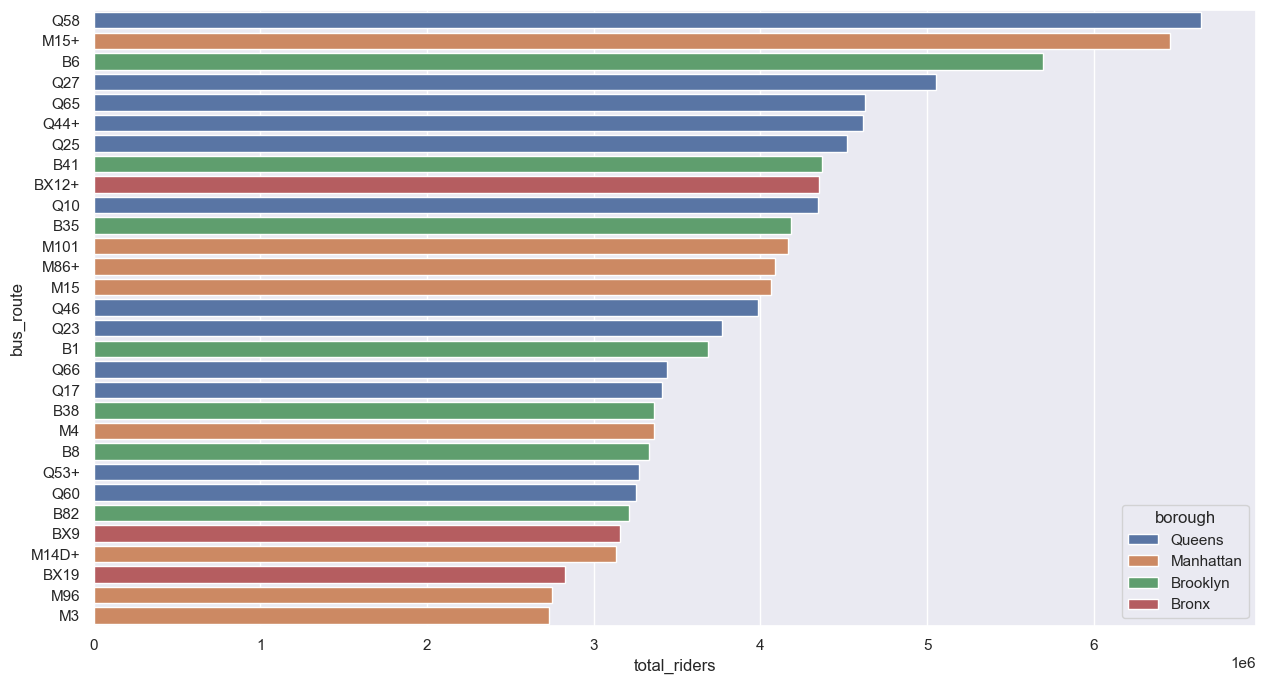

In [16]:
plt.figure(figsize=(15, 8))
sns.barplot(
    data=bus_route_totals_2023.head(30), x="total_riders", y="bus_route", hue="borough"
)

<Axes: xlabel='total_riders', ylabel='bus_route'>

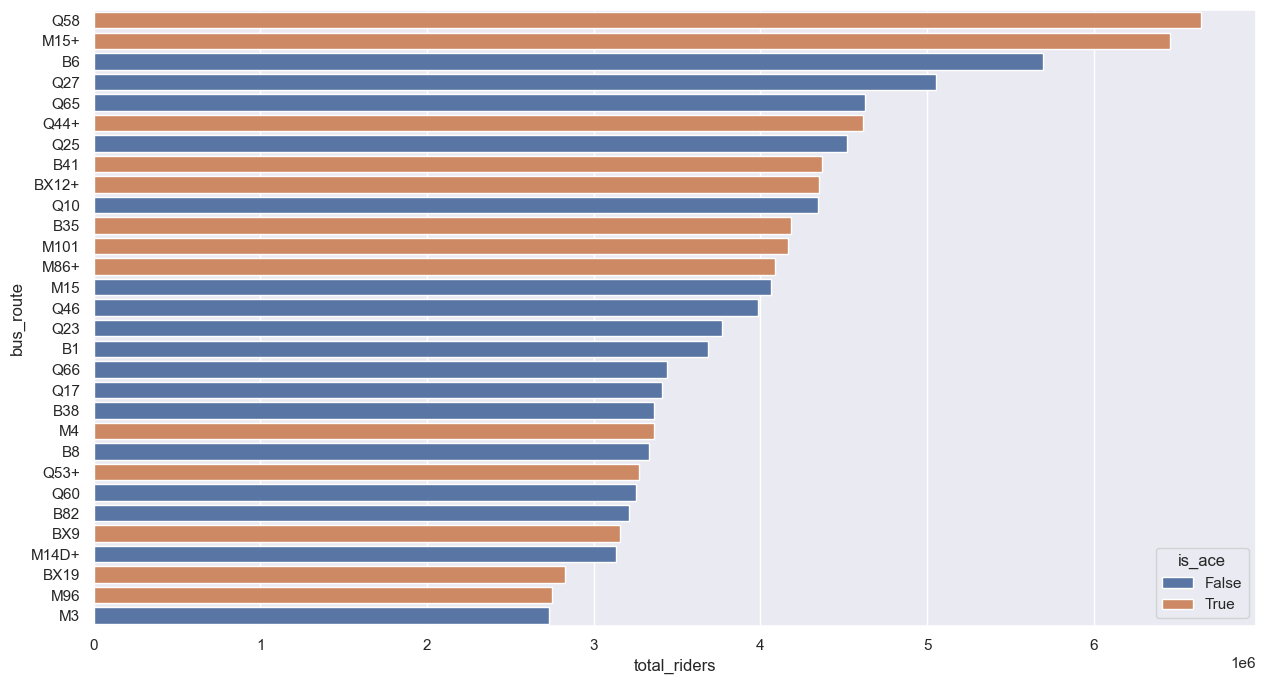

In [17]:
plt.figure(figsize=(15, 8))
sns.barplot(
    data=bus_route_totals_2023.head(30), x="total_riders", y="bus_route", hue="is_ace"
)

<Axes: xlabel='total_riders', ylabel='borough'>

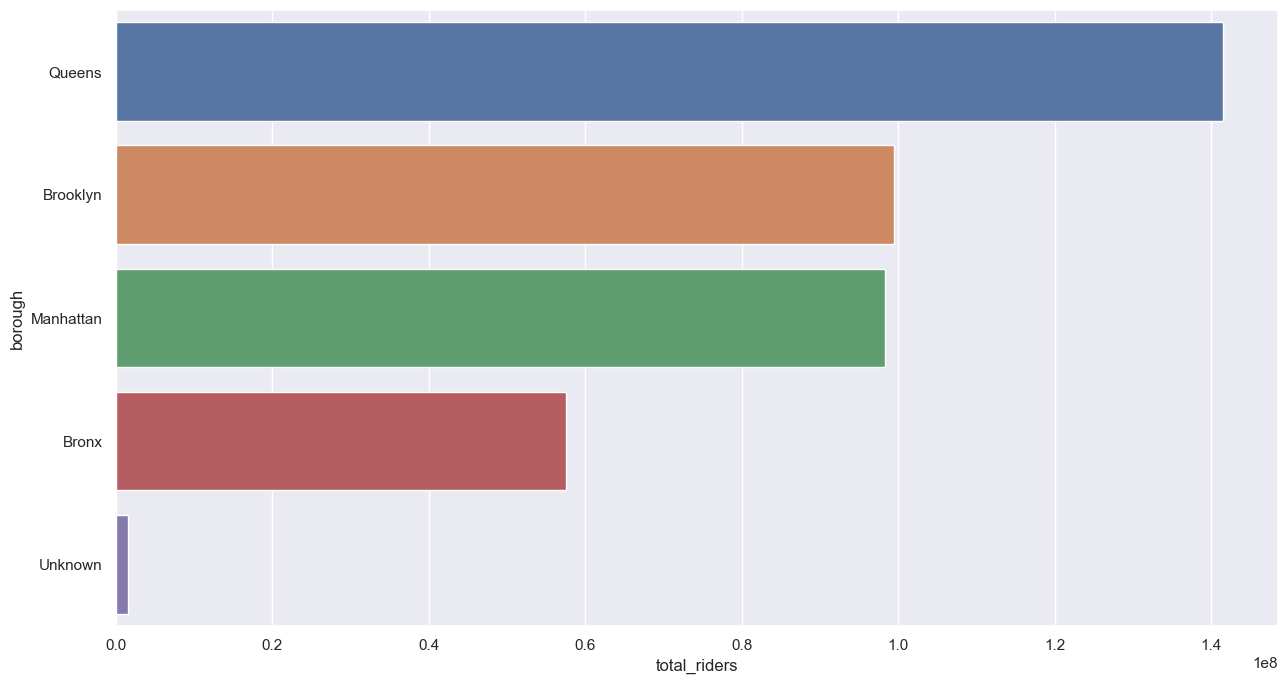

In [18]:
sns.set_theme()
plt.figure(figsize=(15, 8))
sns.barplot(data=borough_totals_2023, x="total_riders", y="borough", hue="borough")

### 2025 Ridership Data


In [19]:
ridership_summary_2025 = qo.pipeline(
    api="ridership-2025",
    query="""
    select
        date_extract_m(transit_timestamp) as month,
        bus_route,
        sum(ridership) as total_riders,
        sum(transfers) as total_transfers
    where
        date_extract_y(transit_timestamp) = 2025
    group by
        month,
        bus_route
    order by
        month asc,
        total_riders desc
    limit 50000
    """,
)
print(ridership_summary_2025.info(), "\n\n\n")
ridership_summary_2025.head(10)

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5100 entries, 0 to 5099
Data columns (total 4 columns):
 #   Column           Non-Null Count  Dtype 
---  ------           --------------  ----- 
 0   month            5100 non-null   int64 
 1   bus_route        5100 non-null   object
 2   total_riders     5100 non-null   int64 
 3   total_transfers  5100 non-null   int64 
dtypes: int64(3), object(1)
memory usage: 159.5+ KB
None 





,month,bus_route,total_riders,total_transfers
0,1,M15+,563136,89973
1,1,Q58,561885,102323
2,1,B6,440250,88815
3,1,Q65,414737,95020
4,1,Q27,407845,86399
5,1,M15,401841,64198
6,1,Q25,384397,82681
7,1,M101,363031,66970
8,1,M86+,344057,88628
9,1,B41,341696,70453


In [20]:
print(ridership_summary_2025["bus_route"].nunique())
print(ridership_summary_2025["month"].nunique())

425
12


In [21]:
ridership_summary_2025["borough"] = ridership_summary_2025["bus_route"].apply(borough)
ridership_summary_2025["is_ace"] = ridership_summary_2025["bus_route"].apply(is_ace)

In [22]:
ridership_summary_2025["is_ace"].value_counts()

is_ace
False    4476
True      624
Name: count, dtype: int64

In [23]:
borough_totals_2025 = ridership_summary_2025.groupby("borough", as_index=False)[
    ["total_riders", "total_transfers"]
].sum()
bus_route_totals_2025 = ridership_summary_2025.groupby("bus_route", as_index=False)[
    ["total_riders", "total_transfers"]
].sum()

In [24]:
bus_route_totals_2025["is_ace"] = bus_route_totals_2025["bus_route"].apply(is_ace)
bus_route_totals_2025["borough"] = bus_route_totals_2025["bus_route"].apply(borough)

bus_route_totals_2025.sort_values(by="total_riders", ascending=False, inplace=True)
borough_totals_2025.sort_values(by="total_riders", ascending=False, inplace=True)

In [25]:
bus_route_totals_2025.head()

,bus_route,total_riders,total_transfers,is_ace,borough
162,M15+,7097225,1189899,True,Manhattan
265,Q58,5828368,1179878,True,Queens
41,B6,5413806,1278785,False,Brooklyn
230,Q25,5280518,1248320,False,Queens
161,M15,4769745,818255,False,Manhattan


In [26]:
borough_totals_2025.head(10)

,borough,total_riders,total_transfers
3,Queens,145024712,33795987
2,Manhattan,107621729,22311008
1,Brooklyn,97763082,21047499
0,Bronx,60024105,12394789
4,Unknown,1624929,119466


<Axes: xlabel='total_riders', ylabel='bus_route'>

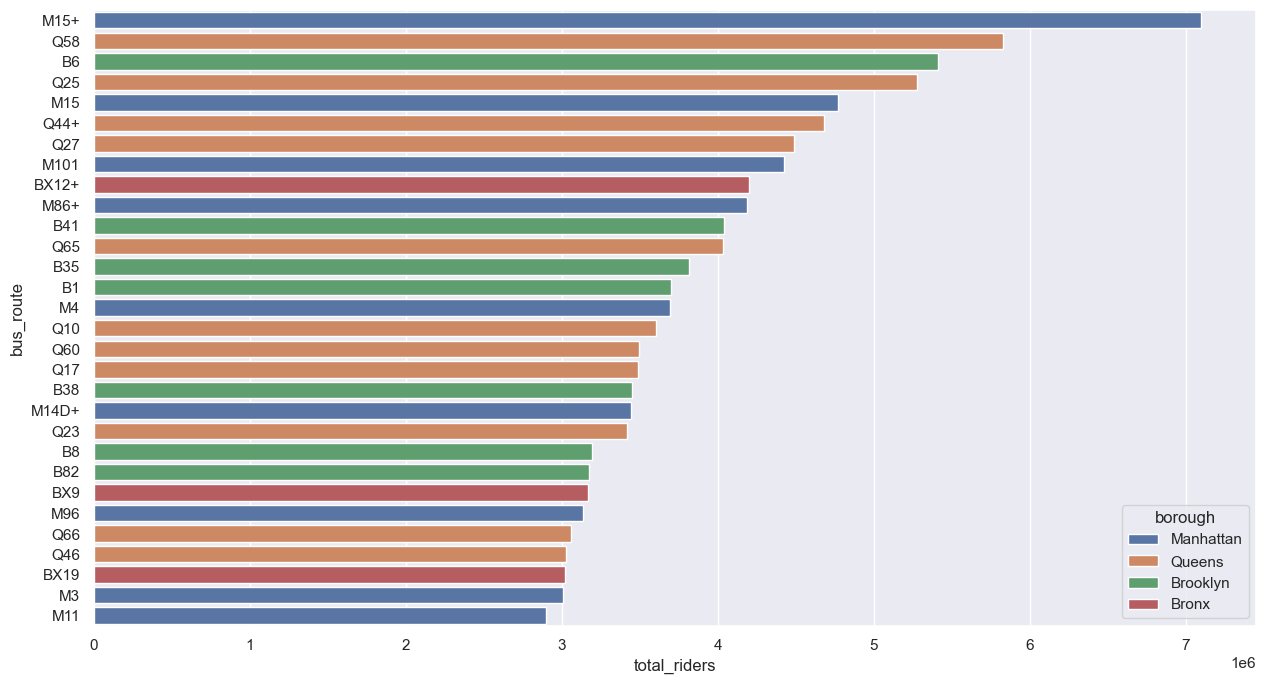

In [27]:
plt.figure(figsize=(15, 8))
sns.barplot(
    data=bus_route_totals_2025.head(30), x="total_riders", y="bus_route", hue="borough"
)

<Axes: xlabel='total_riders', ylabel='bus_route'>

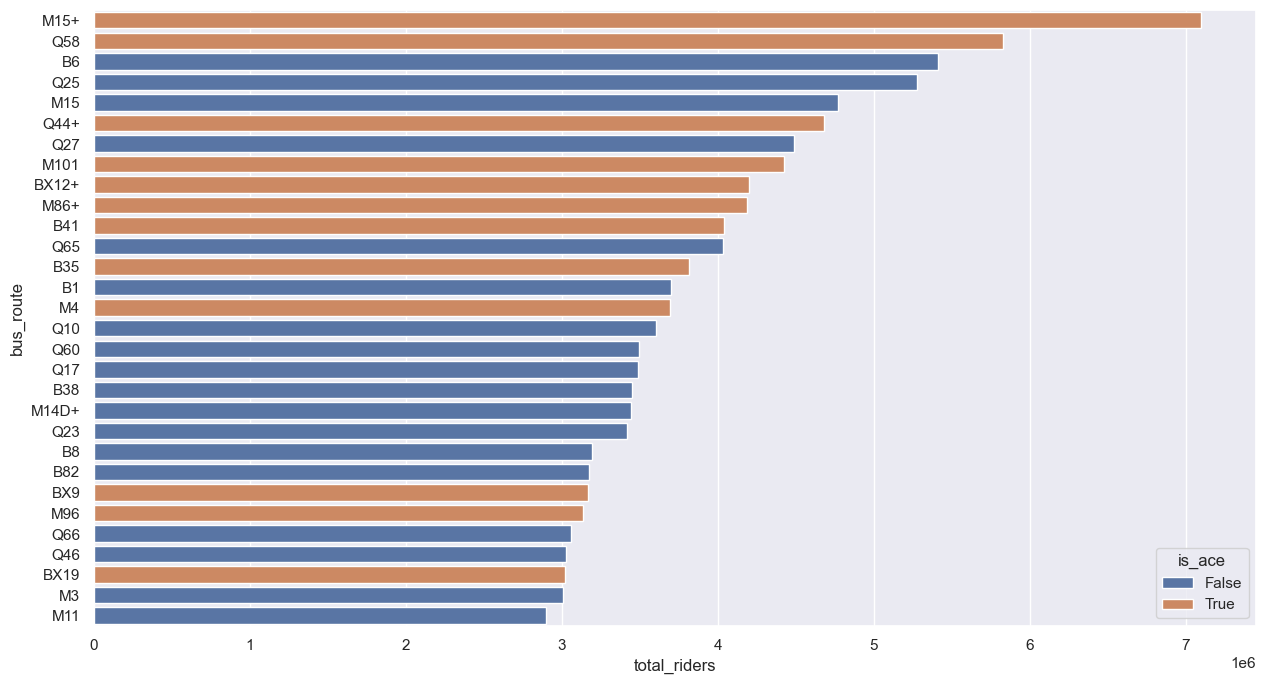

In [28]:
plt.figure(figsize=(15, 8))
sns.barplot(
    data=bus_route_totals_2025.head(30), x="total_riders", y="bus_route", hue="is_ace"
)

<Axes: xlabel='total_riders', ylabel='borough'>

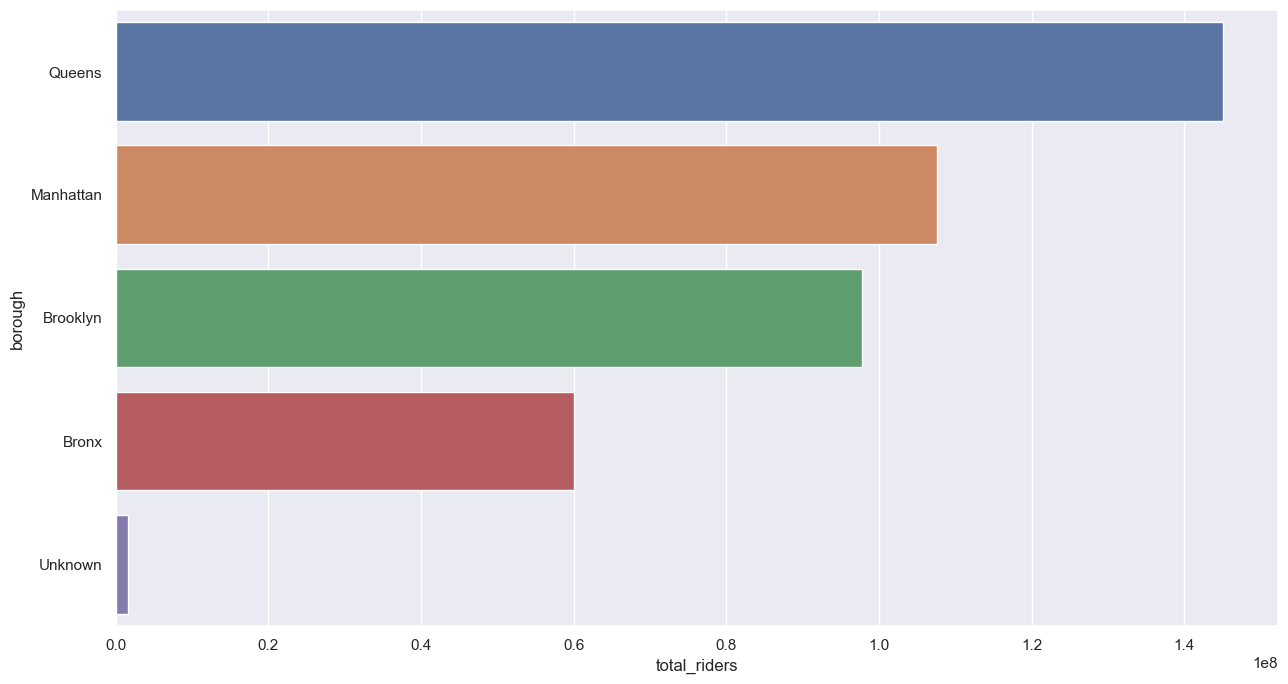

In [29]:
sns.set_theme()
plt.figure(figsize=(15, 8))
sns.barplot(data=borough_totals_2025, x="total_riders", y="borough", hue="borough")

## Statistical Analysis


### Summary


#### 2023


In [30]:
ridership_summary_2023.describe()

,month,total_riders,total_transfers
count,5100.000000,5100.000000,5100.000000
mean,6.500000,78120.400392,14410.895490
std,3.452391,96967.473943,18482.801028
min,1.000000,0.000000,0.000000
25%,3.750000,3977.000000,368.500000
50%,6.500000,40696.500000,7147.000000
75%,9.250000,124116.000000,22835.500000
max,12.000000,612323.000000,106053.000000


In [31]:
borough_totals_2023.describe()

,total_riders,total_transfers
count,5.000000e+00,5.000000e+00
mean,7.968281e+07,1.469911e+07
std,5.277821e+07,1.045554e+07
min,1.591539e+06,1.160280e+05
25%,5.758101e+07,9.680301e+06
50%,9.836081e+07,1.761687e+07
75%,9.941418e+07,1.795568e+07
max,1.414665e+08,2.812669e+07


In [32]:
bus_route_totals_2023.describe()

,total_riders,total_transfers
count,4.250000e+02,4.250000e+02
mean,9.374448e+05,1.729307e+05
std,1.157645e+06,2.204356e+05
min,0.000000e+00,0.000000e+00
25%,5.482100e+04,4.854000e+03
50%,4.861540e+05,8.998600e+04
75%,1.502853e+06,2.685300e+05
max,6.641401e+06,1.107860e+06


#### 2025


In [33]:
ridership_summary_2025.describe()

,month,total_riders,total_transfers
count,5100.000000,5100.000000,5100.000000
mean,6.500000,80795.795490,17582.107647
std,3.452391,97026.031261,21781.345794
min,1.000000,0.000000,0.000000
25%,3.750000,5505.500000,555.000000
50%,6.500000,45734.000000,9534.500000
75%,9.250000,127624.000000,28221.000000
max,12.000000,628020.000000,126860.000000


In [34]:
borough_totals_2025.describe()

,total_riders,total_transfers
count,5.000000e+00,5.000000e+00
mean,8.241171e+07,1.793375e+07
std,5.435832e+07,1.253490e+07
min,1.624929e+06,1.194660e+05
25%,6.002410e+07,1.239479e+07
50%,9.776308e+07,2.104750e+07
75%,1.076217e+08,2.231101e+07
max,1.450247e+08,3.379599e+07


In [35]:
bus_route_totals_2025.describe()

,total_riders,total_transfers
count,4.250000e+02,4.250000e+02
mean,9.695495e+05,2.109853e+05
std,1.140946e+06,2.552058e+05
min,0.000000e+00,0.000000e+00
25%,9.642200e+04,8.966000e+03
50%,5.682320e+05,1.143450e+05
75%,1.517450e+06,3.374490e+05
max,7.097225e+06,1.278785e+06


### Tests


### Percentage differences


In [63]:
ridership_differences = pd.merge(
    bus_route_totals_2023, bus_route_totals_2025, how="inner", on="bus_route"
)
ridership_differences.head()

,bus_route,total_riders_x,total_transfers_x,is_ace_x,borough_x,total_riders_y,total_transfers_y,is_ace_y,borough_y
0,Q58,6641401,1095331,True,Queens,5828368,1179878,True,Queens
1,M15+,6455235,968800,True,Manhattan,7097225,1189899,True,Manhattan
2,B6,5692932,1048388,False,Brooklyn,5413806,1278785,False,Brooklyn
3,Q27,5051118,1016561,False,Queens,4489694,1003479,False,Queens
4,Q65,4626634,973695,False,Queens,4035935,951857,False,Queens


In [ ]:
ridership_differences.drop(
    columns=[
        "is_ace_x",
        "borough_x",
    ],
    inplace=True,
)
ridership_differences.head()

,bus_route,total_riders_x,total_transfers_x,total_riders_y,total_transfers_y,is_ace_y,borough_y
0,Q58,6641401,1095331,5828368,1179878,True,Queens
1,M15+,6455235,968800,7097225,1189899,True,Manhattan
2,B6,5692932,1048388,5413806,1278785,False,Brooklyn
3,Q27,5051118,1016561,4489694,1003479,False,Queens
4,Q65,4626634,973695,4035935,951857,False,Queens


In [ ]:
ridership_differences.rename(
    columns={
        "total_riders_x": "total_riders_2023",
        "total_transfers_x": "total_transfers_2023",
        "total_riders_y": "total_riders_2025",
        "total_transfers_y": "total_transfers_2025",
        "is_ace_y": "is_ace",
        "borough_y": "borough",
    },
    inplace=True,
)

In [66]:
ridership_differences.head()

,bus_route,total_riders_2023,total_transfers_2023,total_riders_2025,total_transfers_2025,is_ace,borough
0,Q58,6641401,1095331,5828368,1179878,True,Queens
1,M15+,6455235,968800,7097225,1189899,True,Manhattan
2,B6,5692932,1048388,5413806,1278785,False,Brooklyn
3,Q27,5051118,1016561,4489694,1003479,False,Queens
4,Q65,4626634,973695,4035935,951857,False,Queens


In [67]:
print(ridership_differences.isna().sum())

bus_route               0
total_riders_2023       0
total_transfers_2023    0
total_riders_2025       0
total_transfers_2025    0
is_ace                  0
borough                 0
dtype: int64


In [68]:
ridership_differences["total_difference"] = (
    ridership_differences["total_riders_2025"]
    - ridership_differences["total_riders_2023"]
)
ridership_differences["percentage_difference"] = (
    (
        ridership_differences["total_riders_2025"]
        - ridership_differences["total_riders_2023"]
    )
    / ridership_differences["total_riders_2023"]
) * 100

In [69]:
ridership_differences.head()

,bus_route,total_riders_2023,total_transfers_2023,total_riders_2025,total_transfers_2025,is_ace,borough,total_difference,percentage_difference
0,Q58,6641401,1095331,5828368,1179878,True,Queens,-813033,-12.241890
1,M15+,6455235,968800,7097225,1189899,True,Manhattan,641990,9.945261
2,B6,5692932,1048388,5413806,1278785,False,Brooklyn,-279126,-4.903027
3,Q27,5051118,1016561,4489694,1003479,False,Queens,-561424,-11.114846
4,Q65,4626634,973695,4035935,951857,False,Queens,-590699,-12.767360


In [70]:
ridership_differences.describe()

c:\Users\drodr\coding\Data-Lions\.venv\Lib\site-packages\pandas\core\nanops.py:1016: RuntimeWarning: invalid value encountered in subtract
  sqr = _ensure_numeric((avg - values) ** 2)


,total_riders_2023,total_transfers_2023,total_riders_2025,total_transfers_2025,total_difference,percentage_difference
count,4.250000e+02,4.250000e+02,4.250000e+02,4.250000e+02,4.250000e+02,380.000000
mean,9.374448e+05,1.729307e+05,9.695495e+05,2.109853e+05,3.210474e+04,inf
std,1.157645e+06,2.204356e+05,1.140946e+06,2.552058e+05,2.179997e+05,NaN
min,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,-9.547600e+05,-100.000000
25%,5.482100e+04,4.854000e+03,9.642200e+04,8.966000e+03,-1.910000e+02,-2.533416
50%,4.861540e+05,8.998600e+04,5.682320e+05,1.143450e+05,1.113700e+04,6.149703
75%,1.502853e+06,2.685300e+05,1.517450e+06,3.374490e+05,6.854800e+04,14.049205
max,6.641401e+06,1.107860e+06,7.097225e+06,1.278785e+06,1.521134e+06,inf


In [ ]:
ridership_differences.groupby("is_ace")[
    ["total_difference", "percentage_difference"]
].agg(["median", "mean"])

total_difference               percentage_difference          
                 median          mean                median      mean
is_ace                                                               
False            9507.0  30060.595174              6.788209       inf
True            71658.0  46767.557692              3.618700  3.994053

In [ ]:
ridership_differences.groupby("borough")[
    ["total_difference", "percentage_difference"]
].agg(["median", "mean"])

total_difference               percentage_difference          
                    median          mean                median      mean
borough                                                                 
Bronx              17113.5  39404.822581              6.533090       inf
Brooklyn              61.0 -22014.706667              1.143302       inf
Manhattan          34207.0  85749.287037              8.562507  9.735046
Queens             12029.0  25598.604317              6.178138       inf
Unknown                0.0    814.390244             11.037253       inf